In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. CARGA Y LIMPIEZA DE DATOS
# ==============================

ruta = "./ventas_2025_clientes_200_v2.csv"
df = pd.read_csv(ruta)

     idVenta        Cliente Genero  Edad      Producto     Categoria  \
73        74    Cliente_F_5      F    18  Producto_281  Categoria_21   
359       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
172       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
375       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
363       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
50        74    Cliente_F_5      F    18  Producto_281  Categoria_21   
258       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
136       74    Cliente_F_5      F    18  Producto_281  Categoria_21   
135      136  Cliente_F_100      F    24  Producto_140  Categoria_34   
40        74    Cliente_F_5      F    18  Producto_281  Categoria_21   
177      178   Cliente_F_95      F    28   Producto_68  Categoria_89   
8          9    Cliente_F_7      F    28  Producto_246   Categoria_9   
303      304   Cliente_M_58      M    32  Producto_174  Categori

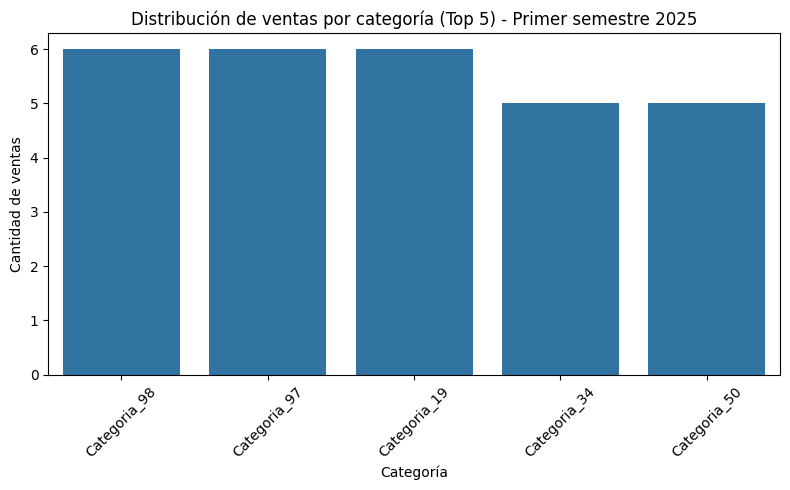

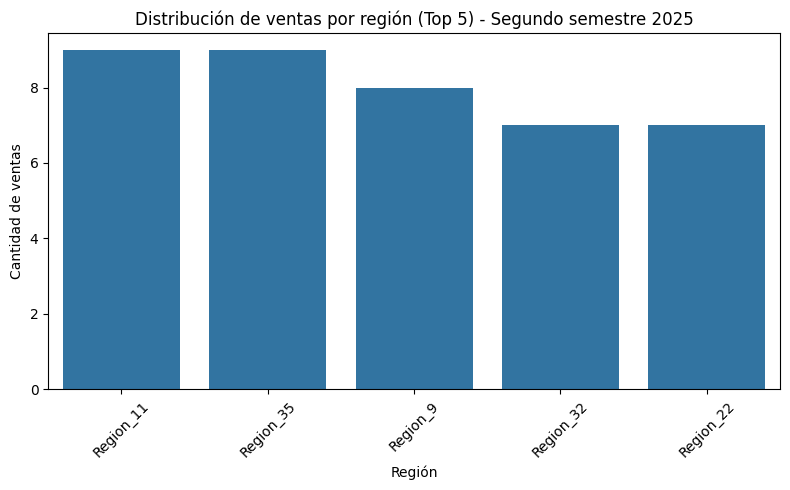

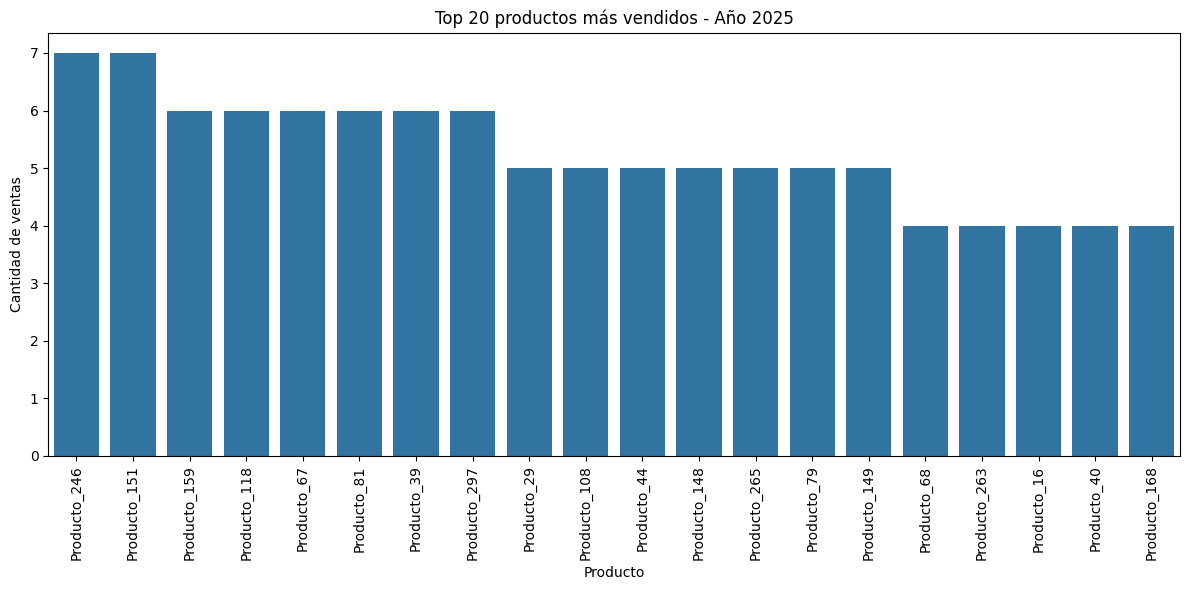


🔥 Top 3 meses con mayores ventas 2025
mes
1     18652.39
7     15890.49
11    13603.25
Name: Total, dtype: float64

❄️ Top 3 meses con menores ventas 2025
mes
8     10506.45
12    10039.33
10     9827.49
Name: Total, dtype: float64

🏆 Top 5 productos más vendidos - Primer semestre 2025
Producto
Producto_246    6
Producto_81     4
Producto_297    4
Producto_159    4
Producto_118    4
Name: count, dtype: int64

🚫 Top 5 productos menos populares - Segundo semestre 2025
Producto
Producto_276    1
Producto_202    1
Producto_259    1
Producto_262    1
Producto_186    1
Name: count, dtype: int64

👨 Top 3 productos comprados por hombres - 2025
Producto
Producto_151    7
Producto_39     6
Producto_246    6
Name: count, dtype: int64

👩 Top 3 productos comprados por mujeres - 2025
Producto
Producto_159    6
Producto_44     5
Producto_36     4
Name: count, dtype: int64


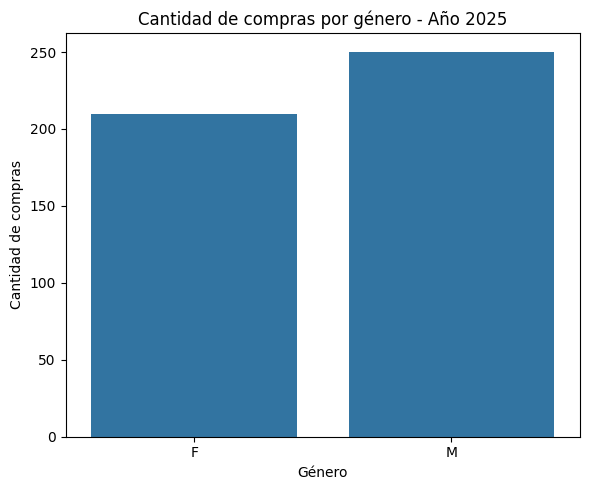

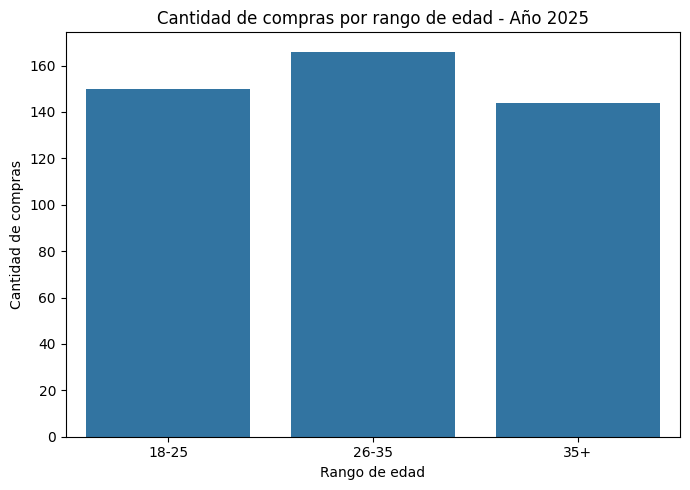


📊 Comparación de comportamiento de compra por género
        total_compras  gasto_promedio  gasto_total
Genero                                            
F                 210          320.63     67331.42
M                 250          327.55     81886.82


In [ ]:

# Filas a omitir explícitamente
filas_a_omitir = [
    73, 359, 172, 375, 363, 50, 258, 136, 135, 40,
    177, 8, 303, 319, 194, 213, 392, 79, 192, 31,
    212, 55, 88, 413, 391, 354, 11, 453, 371, 305,
    148, 113, 139, 376, 344, 351, 416, 186, 218, 235
]


filas_eliminadas = df.loc[filas_a_omitir]

df = df.drop(index=filas_a_omitir, errors="ignore").reset_index(drop=True)

# Mostrar las filas eliminadas
print(filas_eliminadas)

# Conversión de fechas
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.dropna(subset=["Fecha"])

# Columnas auxiliares
df["mes"] = df["Fecha"].dt.month
df["anio"] = df["Fecha"].dt.year

# Filtrar solo 2025
df = df[df["anio"] == 2025]

# Separación por semestres
primer_semestre = df[df["mes"] <= 6]
segundo_semestre = df[df["mes"] > 6]

# ==============================
# 2. ANÁLISIS EXPLORATORIO
# ==============================

def estadisticas_basicas(data, nombre):
    print(f"\n📊 Estadísticas básicas - {nombre}")
    print("Media:", round(data["Total"].mean(), 2))
    print("Mediana:", data["Total"].median())
    print("Moda:", data["Total"].mode().values)

# 2.b Estadísticas por semestre
estadisticas_basicas(primer_semestre, "Primer semestre 2025")
estadisticas_basicas(segundo_semestre, "Segundo semestre 2025")

# ==============================
# 2.c DISTRIBUCIÓN DE VENTAS
# ==============================

# 1️⃣ Primer semestre 2025 - Top 5 categorías
top5_categorias_ps = primer_semestre["Categoria"].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top5_categorias_ps.index, y=top5_categorias_ps.values)
plt.title("Distribución de ventas por categoría (Top 5) - Primer semestre 2025")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2️⃣ Segundo semestre 2025 - Top 5 regiones
top5_regiones_ss = segundo_semestre["Region"].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top5_regiones_ss.index, y=top5_regiones_ss.values)
plt.title("Distribución de ventas por región (Top 5) - Segundo semestre 2025")
plt.xlabel("Región")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3️⃣ Año completo 2025 - Top 20 productos más vendidos
top20_productos = df["Producto"].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top20_productos.index, y=top20_productos.values)
plt.title("Top 20 productos más vendidos - Año 2025")
plt.xlabel("Producto")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ==============================
# 3. ANÁLISIS DE TENDENCIAS
# ==============================

ventas_mensuales = df.groupby("mes")["Total"].sum().sort_values(ascending=False)

print("\n🔥 Top 3 meses con mayores ventas 2025")
print(ventas_mensuales.head(3))

print("\n❄️ Top 3 meses con menores ventas 2025")
print(ventas_mensuales.tail(3))

print("\n🏆 Top 5 productos más vendidos - Primer semestre 2025")
print(primer_semestre["Producto"].value_counts().head(5))

print("\n🚫 Top 5 productos menos populares - Segundo semestre 2025")
print(
    segundo_semestre["Producto"]
    .value_counts()
    .sort_values()
    .head(5)
)

# ==============================
# 4. SEGMENTACIÓN DE CLIENTES
# ==============================

# Rangos de edad solicitados
df["grupo_edad"] = pd.cut(
    df["Edad"],
    bins=[17, 25, 35, 100],
    labels=["18-25", "26-35", "35+"]
)

print("\n👨 Top 3 productos comprados por hombres - 2025")
print(df[df["Genero"] == "M"]["Producto"].value_counts().head(3))

print("\n👩 Top 3 productos comprados por mujeres - 2025")
print(df[df["Genero"] == "F"]["Producto"].value_counts().head(3))

# ---- Compras por género ----
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Genero")
plt.title("Cantidad de compras por género - Año 2025")
plt.xlabel("Género")
plt.ylabel("Cantidad de compras")
plt.tight_layout()
plt.show()

# ---- Compras por rango de edad ----
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="grupo_edad")
plt.title("Cantidad de compras por rango de edad - Año 2025")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de compras")
plt.tight_layout()
plt.show()

# ==============================
# 4.b COMPARACIÓN ENTRE GÉNEROS
# ==============================

print("\n📊 Comparación de comportamiento de compra por género")

comparacion_genero = df.groupby("Genero")["Total"].agg(
    total_compras="count",
    gasto_promedio="mean",
    gasto_total="sum"
)

print(comparacion_genero.round(2))
